# 3.17 Sea Star GAN
[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ada-carter/cv/blob/main/book/Sea_Star_GAN.ipynb)

Generative Adversarial Networks solve a problem that has no clean supervised learning solution: synthesizing new examples of a category when you do not have enough real examples to train on. In marine computer vision, that problem is a constant. Many species of interest are rarely encountered, difficult to photograph, or found at depths that require expensive equipment. The result is that even well-curated datasets tend to be small and imbalanced. A detector trained on 200 images of one species and 2000 of another will systematically underperform on the minority class, regardless of how sophisticated the architecture is.

GANs address this directly by learning the image distribution from the available examples and then sampling new images from that distribution. If the generator learns the distribution well, the synthetic images it produces are statistically consistent with the real ones and can be used to pad the training set for the minority class.

This notebook trains a Deep Convolutional GAN (DCGAN) on a dataset of sea star images. The architecture follows the original DCGAN paper: the generator uses transposed convolutions to upsample a 100-dimensional noise vector into a 64x64 RGB image, and the discriminator uses strided convolutions to classify images as real or fake. Training alternates between updating the discriminator and updating the generator, with each network receiving gradients calculated from the binary cross-entropy loss on its respective objective.

The training run is divided into four 200-epoch blocks so you can evaluate output quality at each stage. By comparing the generated grids across rounds, you will observe the full arc of GAN training from structured noise to recognizable synthetic organisms.

**Prerequisites:** Lessons 3.1 through 3.16. Familiarity with convolutional neural networks, binary cross-entropy loss, and backpropagation.

**Expected runtime:** Approximately 30 to 45 minutes on a Colab T4 GPU across all four training blocks.

In [1]:
import os
import urllib.request
import zipfile

dataset_url = "https://storage.googleapis.com/public-datasets-lila/sea-star-re-id/sea-star-re-id.zip"
zip_path = "sea-star-re-id.zip"
extract_dir = "seastar_data"

if not os.path.exists(zip_path):
    print("Downloading dataset...")
    urllib.request.urlretrieve(dataset_url, zip_path)
    print("Download complete.")

if not os.path.exists(extract_dir):
    print("Extracting dataset...")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_dir)
    print("Extraction complete.")

Download complete.
Extracting dataset...
Extraction complete.


In [18]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import glob
import matplotlib.pyplot as plt
import numpy as np
import os

# Find all ASRU images
asru_images = glob.glob(os.path.join(extract_dir, 'sea-star-re-id', 'Anau*', '*.jpg'))
print(f"Found {len(asru_images)} Anthenea australiae images.")

class SeaStarDataset(Dataset):
    def __init__(self, image_paths, transform=None):
        self.image_paths = image_paths
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img = Image.open(self.image_paths[idx]).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img

# Transform for DCGAN
image_size = 64
batch_size = 256

transform = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

dataset = SeaStarDataset(asru_images, transform=transform)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True, num_workers=12, pin_memory=True)


Found 983 Anthenea australiae images.


In [19]:
import torch.nn as nn

nz = 100 # Size of latent vector (generator input)

class Generator(nn.Module):
    def __init__(self):
        super(Generator, self).__init__()
        self.main = nn.Sequential(
            nn.ConvTranspose2d(nz, 512, 4, 1, 0, bias=False),
            nn.BatchNorm2d(512),
            nn.ReLU(True),
            nn.ConvTranspose2d(512, 256, 4, 2, 1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(True),
            nn.ConvTranspose2d(256, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(True),
            nn.ConvTranspose2d(128, 64, 4, 2, 1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(True),
            nn.ConvTranspose2d(64, 3, 4, 2, 1, bias=False),
            nn.Tanh()
        )

    def forward(self, input):
        return self.main(input)

class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()
        self.main = nn.Sequential(
            nn.Conv2d(3, 64, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(64, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(128, 256, 4, 2, 1, bias=False),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(256, 512, 4, 2, 1, bias=False),
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(512, 1, 4, 1, 0, bias=False),
            nn.Sigmoid()
        )

    def forward(self, input):
        return self.main(input)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
netG = Generator().to(device)
netD = Discriminator().to(device)


In [20]:
print(f"Currently using device: {device}")
if device.type == 'cuda':
    print(f"GPU Model: {torch.cuda.get_device_name(0)}")

Currently using device: cuda
GPU Model: NVIDIA A100-SXM4-40GB


In [22]:
import torch.optim as optim
import torch.backends.cudnn as cudnn

# Enable cudnn benchmark for faster convolutions on fixed-size inputs
cudnn.benchmark = True

criterion = nn.BCELoss()
optimizerD = optim.Adam(netD.parameters(), lr=0.0001, betas=(0.5, 0.999))
optimizerG = optim.Adam(netG.parameters(), lr=0.0002, betas=(0.5, 0.999))

epochs = 100

print("Starting Training Loop with CPU or GPU...")
for epoch in range(epochs):
    for i, data in enumerate(dataloader, 0):
        # 1. Update Discriminator
        netD.zero_grad()
        real_cpu = data.to(device)
        b_size = real_cpu.size(0)
        label = torch.full((b_size,), 0.9, dtype=torch.float, device=device)
        output = netD(real_cpu).view(-1)
        errD_real = criterion(output, label)
        errD_real.backward()

        noise = torch.randn(b_size, nz, 1, 1, device=device)
        fake = netG(noise)
        label.fill_(0.)
        output = netD(fake.detach()).view(-1)
        errD_fake = criterion(output, label)
        errD_fake.backward()
        optimizerD.step()

        # 2. Update Generator
        netG.zero_grad()
        label.fill_(1.)  # fake labels are real for generat r cost
        output = netD(fake).view(-1)
        errG = criterion(output, label)
        errG.backward()
        optimizerG.step()

    print(f'[{epoch+1}/{epochs}] Loss_D: {errD_real.item() + errD_fake.item():.4f} Loss_G: {errG.item():.4f}')

Starting Training Loop with CPU or GPU...
[1/100] Loss_D: 1.1177 Loss_G: 4.2531
[2/100] Loss_D: 1.1838 Loss_G: 2.9743
[3/100] Loss_D: 0.9467 Loss_G: 3.3412
[4/100] Loss_D: 0.9256 Loss_G: 3.0027
[5/100] Loss_D: 0.8672 Loss_G: 3.8548
[6/100] Loss_D: 0.7440 Loss_G: 4.0515
[7/100] Loss_D: 1.1023 Loss_G: 4.7933
[8/100] Loss_D: 0.8798 Loss_G: 4.8080
[9/100] Loss_D: 0.8376 Loss_G: 3.7502
[10/100] Loss_D: 1.2272 Loss_G: 3.5025
[11/100] Loss_D: 0.9334 Loss_G: 2.0551
[12/100] Loss_D: 0.9727 Loss_G: 3.0524
[13/100] Loss_D: 0.7586 Loss_G: 3.3222
[14/100] Loss_D: 0.9670 Loss_G: 2.9214
[15/100] Loss_D: 0.9180 Loss_G: 3.1201
[16/100] Loss_D: 0.9176 Loss_G: 3.2538
[17/100] Loss_D: 0.8420 Loss_G: 2.6973
[18/100] Loss_D: 0.8553 Loss_G: 2.7976
[19/100] Loss_D: 0.8913 Loss_G: 2.9173
[20/100] Loss_D: 0.9632 Loss_G: 3.6935
[21/100] Loss_D: 0.6893 Loss_G: 3.4118
[22/100] Loss_D: 0.8196 Loss_G: 2.7601
[23/100] Loss_D: 0.9063 Loss_G: 3.5906
[24/100] Loss_D: 0.8778 Loss_G: 3.4762
[25/100] Loss_D: 1.0989 Loss_G:

### Evaluating Generator Output (Round 1)

After 100 initial training epochs, the generator has had enough iterations to develop rough structural responses to the input noise, but not enough to produce fine texture or sharp edges. The output grid at this stage typically shows blurry, low-frequency blobs that gesture toward sea star shapes without committing to them. That is normal and expected.

The reason the early outputs are soft rather than incoherent noise comes down to label smoothing. Instead of training the discriminator to classify real images with a target label of 1.0, the code uses 0.9. This small adjustment prevents the discriminator from becoming overconfident during the first few hundred batches. An overconfident discriminator produces gradients that are nearly zero at its output, which propagates almost no learning signal back through the generator. Label smoothing keeps the discriminator's confidence slightly uncertain, preserving a usable gradient for the generator to learn from.

Look at the 16-image grid and ask: do you see any shapes that are consistent across multiple samples? Consistent shape emergence, even without detail, is the sign that training is proceeding normally. Uniform gray or pure noise at this stage would indicate a problem with the generator architecture or the learning rate balance between the two networks.

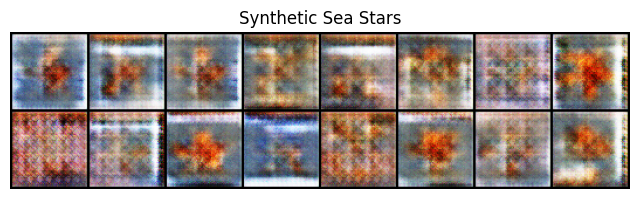

In [23]:
import torchvision.utils as vutils

# Generate a batch of fake images
noise = torch.randn(16, nz, 1, 1, device=device)
with torch.no_grad():
    fake_images = netG(noise).detach().cpu()

# Plot the fake images
plt.figure(figsize=(8,8))
plt.axis("off")
plt.title("Synthetic Sea Stars")
plt.imshow(np.transpose(vutils.make_grid(fake_images, padding=2, normalize=True), (1, 2, 0)))
plt.show()

### Continuing Adversarial Training

GAN training is a two-player minimax game. The generator attempts to minimize its loss (fool the discriminator), while the discriminator attempts to maximize its accuracy (correctly classify real versus fake). In theory these objectives push toward a Nash equilibrium where the generator produces images indistinguishable from real ones and the discriminator is no better than a coin flip. In practice, that equilibrium is rarely reached cleanly, and the dynamics of getting there require careful monitoring.

Watch the loss trends across these additional 200-epoch blocks. Neither network should consistently dominate:

- If the **discriminator loss collapses to near zero**, the discriminator has learned to identify fakes trivially. The generator is receiving a near-zero gradient and is no longer improving. This is called discriminator dominance.
- If the **generator loss climbs steadily**, the discriminator is too powerful relative to the generator's current capacity. The adversarial signal is present but too harsh for productive learning.
- A **healthy training run** shows both losses fluctuating within a moderate range, with neither trending monotonically toward zero or infinity. Some oscillation is normal and expected.

Each 200-epoch block in this notebook is deliberately short so you can observe the loss trajectory and generated image quality at multiple checkpoints rather than waiting for a single long run to complete.

In [24]:
additional_epochs = 200

print(f"Resuming Training Loop for {additional_epochs} more epochs...")
for epoch in range(additional_epochs):
    for i, data in enumerate(dataloader, 0):
        # 1. Update Discriminator
        netD.zero_grad()
        real_cpu = data.to(device)
        b_size = real_cpu.size(0)

        # Real labels are smoothed to 0.9
        label = torch.full((b_size,), 0.9, dtype=torch.float, device=device)
        output = netD(real_cpu).view(-1)
        errD_real = criterion(output, label)
        errD_real.backward()

        noise = torch.randn(b_size, nz, 1, 1, device=device)
        fake = netG(noise)
        label.fill_(0.)
        output = netD(fake.detach()).view(-1)
        errD_fake = criterion(output, label)
        errD_fake.backward()
        optimizerD.step()

        # 2. Update Generator
        netG.zero_grad()
        label.fill_(1.)  # fake labels are real for generator cost
        output = netD(fake).view(-1)
        errG = criterion(output, label)
        errG.backward()
        optimizerG.step()

    print(f'[Continued {epoch+1}/{additional_epochs}] Loss_D: {errD_real.item() + errD_fake.item():.4f} Loss_G: {errG.item():.4f}')

Resuming Training Loop for 200 more epochs...
[Continued 1/200] Loss_D: 0.6997 Loss_G: 2.8628
[Continued 2/200] Loss_D: 1.3260 Loss_G: 3.3962
[Continued 3/200] Loss_D: 0.7051 Loss_G: 2.2087
[Continued 4/200] Loss_D: 0.8782 Loss_G: 3.6395
[Continued 5/200] Loss_D: 0.7103 Loss_G: 2.9983
[Continued 6/200] Loss_D: 0.7363 Loss_G: 3.8512
[Continued 7/200] Loss_D: 0.6538 Loss_G: 2.7795
[Continued 8/200] Loss_D: 0.6657 Loss_G: 3.1862
[Continued 9/200] Loss_D: 0.6857 Loss_G: 2.2930
[Continued 10/200] Loss_D: 0.6840 Loss_G: 2.7473
[Continued 11/200] Loss_D: 0.8860 Loss_G: 4.3787
[Continued 12/200] Loss_D: 0.6071 Loss_G: 2.4680
[Continued 13/200] Loss_D: 0.6982 Loss_G: 2.7549
[Continued 14/200] Loss_D: 0.8147 Loss_G: 3.5478
[Continued 15/200] Loss_D: 0.8307 Loss_G: 5.0624
[Continued 16/200] Loss_D: 0.8088 Loss_G: 2.2432
[Continued 17/200] Loss_D: 0.6555 Loss_G: 3.7278
[Continued 18/200] Loss_D: 0.8412 Loss_G: 2.8611
[Continued 19/200] Loss_D: 0.6813 Loss_G: 3.1221
[Continued 20/200] Loss_D: 0.690

### Evaluating Generator Output (Round 2)

By 300 epochs, the generator has completed 300 full passes over the dataset, and each pass has updated its weights based on gradient signals from the discriminator. The images at this stage should show more committed structural features than at round one: cleaner edges, more consistent radial symmetry, and some attempt at the texture variation visible in real sea star arms.

This is also the stage where the first failure modes become clearly distinguishable from progress. If you see a grid with 16 nearly identical outputs, the generator has collapsed onto a single mode of the data distribution. The discriminator classifies that one output as plausibly real, so the generator has no incentive to explore further. This is **mode collapse**, and it is the most common failure in DCGAN training.

If the images remain blurry but show diverse structural variations across the 16 samples, training is progressing normally. Diversity of form across the grid is the primary indicator of a healthy generator at this stage, ahead of sharpness.

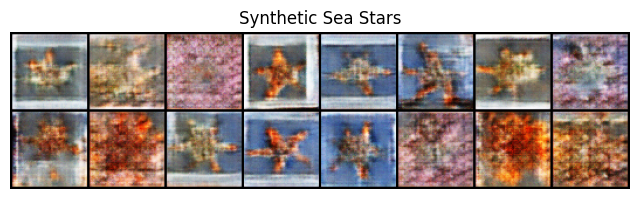

In [25]:
import torchvision.utils as vutils

# Generate a batch of fake images
noise = torch.randn(16, nz, 1, 1, device=device)
with torch.no_grad():
    fake_images = netG(noise).detach().cpu()

# Plot the fake images
plt.figure(figsize=(8,8))
plt.axis("off")
plt.title("Synthetic Sea Stars")
plt.imshow(np.transpose(vutils.make_grid(fake_images, padding=2, normalize=True), (1, 2, 0)))
plt.show()

### Third Training Block: Epochs 301 to 500

At this point in training, the generator has established basic structural patterns and the discriminator has adapted to them. The next 200 epochs tend to produce the steepest visible improvements in image quality, because both networks are operating in a regime where neither has completely outpaced the other.

Pay particular attention to the loss values printed at the end of each epoch. The discriminator loss on real images (`D(x)`) and on fake images (`D(G(z))`) are printed alongside the total generator and discriminator losses. Ideally, `D(x)` should remain close to 1 (real images classified as real) and `D(G(z))` should be gradually moving from near 0 (fakes correctly identified) toward something closer to 0.5 (fakes becoming difficult to distinguish). That convergence in the fake classification confidence is the quantitative sign that the generator is improving.

In [26]:
additional_epochs = 200

print(f"Resuming Training Loop for {additional_epochs} more epochs...")
for epoch in range(additional_epochs):
    for i, data in enumerate(dataloader, 0):
        # 1. Update Discriminator
        netD.zero_grad()
        real_cpu = data.to(device)
        b_size = real_cpu.size(0)

        # Real labels are smoothed to 0.9
        label = torch.full((b_size,), 0.9, dtype=torch.float, device=device)
        output = netD(real_cpu).view(-1)
        errD_real = criterion(output, label)
        errD_real.backward()

        noise = torch.randn(b_size, nz, 1, 1, device=device)
        fake = netG(noise)
        label.fill_(0.)
        output = netD(fake.detach()).view(-1)
        errD_fake = criterion(output, label)
        errD_fake.backward()
        optimizerD.step()

        # 2. Update Generator
        netG.zero_grad()
        label.fill_(1.)  # fake labels are real for generator cost
        output = netD(fake).view(-1)
        errG = criterion(output, label)
        errG.backward()
        optimizerG.step()

    print(f'[Continued {epoch+1}/{additional_epochs}] Loss_D: {errD_real.item() + errD_fake.item():.4f} Loss_G: {errG.item():.4f}')

Resuming Training Loop for 200 more epochs...
[Continued 1/200] Loss_D: 0.5125 Loss_G: 2.6331
[Continued 2/200] Loss_D: 0.7372 Loss_G: 4.9431
[Continued 3/200] Loss_D: 0.5192 Loss_G: 2.5715
[Continued 4/200] Loss_D: 0.6224 Loss_G: 2.5084
[Continued 5/200] Loss_D: 0.5406 Loss_G: 2.9801
[Continued 6/200] Loss_D: 0.5834 Loss_G: 3.8782
[Continued 7/200] Loss_D: 0.5122 Loss_G: 3.1230
[Continued 8/200] Loss_D: 0.5397 Loss_G: 2.4609
[Continued 9/200] Loss_D: 0.4761 Loss_G: 3.2155
[Continued 10/200] Loss_D: 0.4869 Loss_G: 2.8480
[Continued 11/200] Loss_D: 0.4990 Loss_G: 3.0622
[Continued 12/200] Loss_D: 0.4963 Loss_G: 2.8355
[Continued 13/200] Loss_D: 0.5681 Loss_G: 2.0161
[Continued 14/200] Loss_D: 0.6147 Loss_G: 3.4867
[Continued 15/200] Loss_D: 0.5416 Loss_G: 3.3553
[Continued 16/200] Loss_D: 0.8893 Loss_G: 5.6782
[Continued 17/200] Loss_D: 0.4675 Loss_G: 3.1192
[Continued 18/200] Loss_D: 0.4804 Loss_G: 3.0038
[Continued 19/200] Loss_D: 0.4884 Loss_G: 2.6657
[Continued 20/200] Loss_D: 0.544

### Evaluating Generator Output (Round 3)

At 500 epochs, the generator has had substantial opportunity to develop the multi-scale features that distinguish recognizable synthetic sea stars from structured noise. At this resolution (64x64 pixels), the realistic upper bound on quality is already fairly close: the network does not have enough parameters or spatial resolution to reconstruct photographic detail, but it should be producing shapes with five-fold symmetry, coherent arm textures, and distinct foreground-background separation.

Look for the following specific quality indicators in the 16-image grid:

- **Arm definition**: Are the arms distinct from the body, or does the whole shape blur together?
- **Color distribution**: Is the color palette consistent across samples, or does it vary in ways that reflect actual sea star coloration?
- **Background handling**: Is the background relatively uniform, or does it contain artifact patterns that reveal the generator is struggling?

Diversity across the 16 samples remains as important as individual image quality. A generator that produces one or two convincing images and fourteen near-duplicates is still exhibiting partial mode collapse.

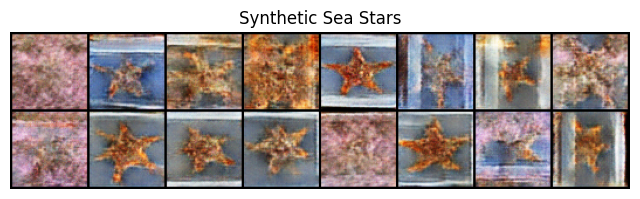

In [27]:
import torchvision.utils as vutils

# Generate a batch of fake images
noise = torch.randn(16, nz, 1, 1, device=device)
with torch.no_grad():
    fake_images = netG(noise).detach().cpu()

# Plot the fake images
plt.figure(figsize=(8,8))
plt.axis("off")
plt.title("Synthetic Sea Stars")
plt.imshow(np.transpose(vutils.make_grid(fake_images, padding=2, normalize=True), (1, 2, 0)))
plt.show()

### Final Training Block: Epochs 501 to 700

This is the last training block before the final evaluation. At 700 total epochs, a DCGAN on a small, relatively uniform dataset like this one has generally reached whatever quality ceiling the architecture and dataset size will allow. Further training past this point tends to yield diminishing returns or, in some cases, degradation if the discriminator has become too well-calibrated and is suppressing the generator's gradient.

The final state of both networks depends heavily on initial random seed values, dataset size, and the stability of the loss dynamics you observed in earlier rounds. Two students running this notebook from scratch with the same code but different GPU hardware may see noticeably different output quality at this stage, because small differences in floating-point timing and batch ordering affect the entire training trajectory.

In [ ]:
additional_epochs = 200

print(f"Resuming Training Loop for {additional_epochs} more epochs...")
for epoch in range(additional_epochs):
    for i, data in enumerate(dataloader, 0):
        # 1. Update Discriminator
        netD.zero_grad()
        real_cpu = data.to(device)
        b_size = real_cpu.size(0)

        # Real labels are smoothed to 0.9
        label = torch.full((b_size,), 0.9, dtype=torch.float, device=device)
        output = netD(real_cpu).view(-1)
        errD_real = criterion(output, label)
        errD_real.backward()

        noise = torch.randn(b_size, nz, 1, 1, device=device)
        fake = netG(noise)
        label.fill_(0.)
        output = netD(fake.detach()).view(-1)
        errD_fake = criterion(output, label)
        errD_fake.backward()
        optimizerD.step()

        # 2. Update Generator
        netG.zero_grad()
        label.fill_(1.)  # fake labels are real for generator cost
        output = netD(fake).view(-1)
        errG = criterion(output, label)
        errG.backward()
        optimizerG.step()

    print(f'[Continued {epoch+1}/{additional_epochs}] Loss_D: {errD_real.item() + errD_fake.item():.4f} Loss_G: {errG.item():.4f}')

### Final Output at Full Scale

This cell generates 32 images arranged in a 4-by-8 grid, giving you a larger sample to assess two properties that are invisible in a 16-image grid: diversity and systematic artifact patterns.

**Diversity** is the primary concern for data augmentation use cases. If you intend to use these synthetic images to expand a training set, you need the generated distribution to cover the real distribution's full range, not just a single representative example. Scan the grid for mode collapse: if all 32 images look nearly identical (same arm configuration, same coloring, same background), the generator has found a single output that fools the discriminator and stopped exploring.

**Artifact patterns** reveal architectural limitations. Checkerboard artifacts, which appear as a regular grid of light and dark squares superimposed on the image content, are a known side effect of transpose convolutions when the kernel size is not divisible by the stride. If you see them, they indicate aliasing in the upsampling layers rather than a training failure.

Compare this grid with the first 16-image grid from 100 epochs. The improvement in sharpness and structural coherence across that span is the clearest visual record of what 700 epochs of adversarial training actually accomplishes.

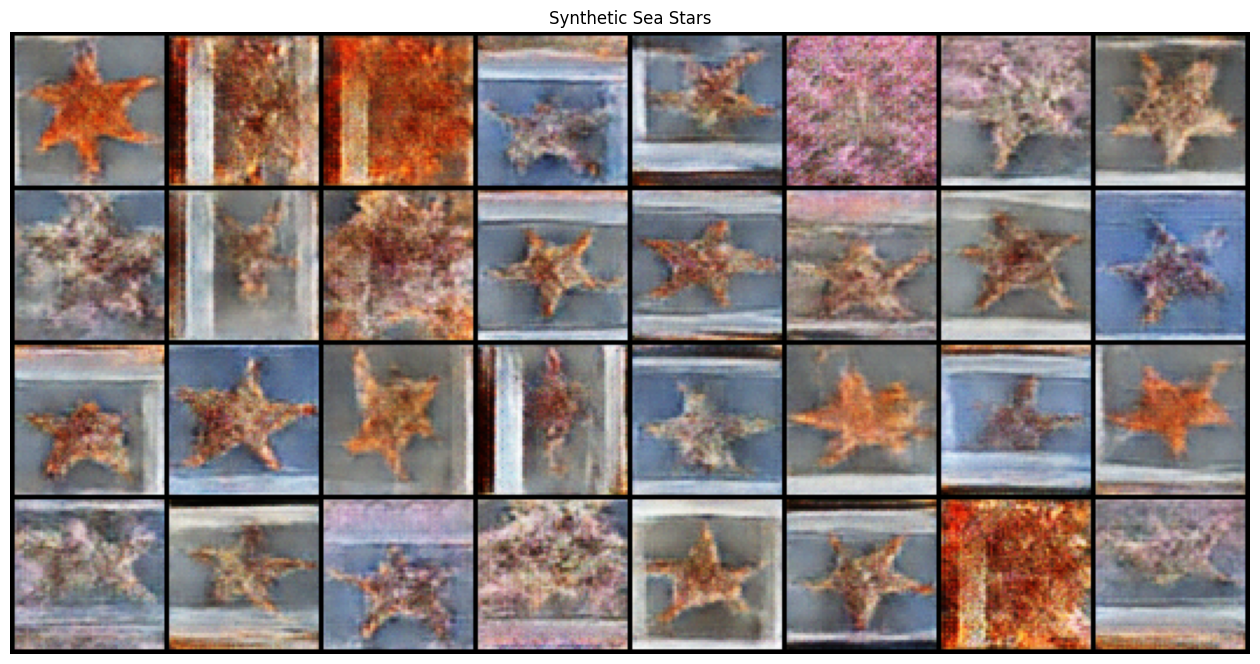

In [30]:
import torchvision.utils as vutils

# Generate a batch of fake images
noise = torch.randn(32, nz, 1, 1, device=device)
with torch.no_grad():
    fake_images = netG(noise).detach().cpu()

# Plot the fake images
plt.figure(figsize=(16,16))
plt.axis("off")
plt.title("Synthetic Sea Stars")
plt.imshow(np.transpose(vutils.make_grid(fake_images, padding=2, normalize=True), (1, 2, 0)))
plt.show()

### Saving Model Weights

The two `torch.save()` calls write the generator and discriminator state dictionaries to `.pth` files, then the Colab `files.download()` utility triggers a browser download so the weights are preserved beyond the session.

Saving `netG_weights.pth` is the most practically important step. The generator's learned weights encode everything the network discovered about the distribution of sea star imagery: shape, texture, color range, and the spatial relationships between arm structures. You can reload these weights at any later point using `netG.load_state_dict(torch.load('netG_weights.pth'))` and immediately generate additional synthetic samples without repeating the full training run.

The discriminator weights (`netD_weights.pth`) are also saved for two reasons. First, if you want to resume training on new data, you need both networks in their current state so the adversarial balance is preserved from where it left off. Second, trained discriminators can serve as feature extractors in their own right: the internal representations a discriminator learns in order to distinguish real from fake images often encode useful perceptual features that transfer to classification and anomaly detection tasks.

In [31]:
from google.colab import files
import torch

# Save the weights to local files
torch.save(netG.state_dict(), 'netG_weights.pth')
torch.save(netD.state_dict(), 'netD_weights.pth')

# Trigger the download
files.download('netG_weights.pth')
files.download('netD_weights.pth')

print("Downloading weights...")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### Reflecting on Results

Review the generated image grids from each training stage before answering these questions.

1. At roughly what epoch count did the generated images first become recognizable as sea stars rather than noise or abstract blobs? What changes in the generator loss and discriminator loss coincided with that transition? Look for the point where the discriminator loss stops collapsing toward zero and the two losses begin to track each other more closely.

2. Frechet Inception Distance (FID) is the standard quantitative metric for GAN output quality. FID computes feature-space statistics (mean and covariance) of real and generated images using an Inception-v3 network, then measures the distance between the two distributions. A lower FID indicates that generated images are closer to real ones in perceptual feature space. How would you set up an FID evaluation here, and what FID score would you consider acceptable for a training data augmentation use case?

3. Which other rare or difficult-to-photograph marine species would benefit most from GAN-based augmentation? Consider animals whose rarity, depth range, or behavioral unpredictability makes large annotated datasets practically impossible to collect, and explain what properties of those species might make GAN training more or less tractable.